### Komparasi Grid Search dan PSO pada algoritma SVM untuk klasifikasi penyakit Diabetes Mellitus

#### 0. Setup & Import Library

In [1]:
# ============================================================
# IMPORT LIBRARY
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import (
    train_test_split, GridSearchCV,
    cross_val_score, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    classification_report, confusion_matrix
)

import joblib
import time
import os
import warnings

warnings.filterwarnings('ignore')
print('Semua library berhasil di-import!')

Semua library berhasil di-import!


In [2]:
# ============================================================
# KONFIGURASI GLOBAL
# ============================================================

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'figure.dpi': 100
})

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.4f}'.format)

RAW_DATA_PATH = '../data/raw/diabetes_dataset.csv'
PROCESSED_DIR = '../data/processed/'
RESULTS_DIR = '../results/'
FIGURES_DIR = '../results/figures/'

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f'Random State : {RANDOM_STATE}')
print(f'Raw Data Path: {RAW_DATA_PATH}')
print('Konfigurasi selesai!')

Random State : 42
Raw Data Path: ../data/raw/diabetes_dataset.csv
Konfigurasi selesai!


---
### 1. Explanatory Data Analysis (EDA)

**1.1 Pemahaman Struktur Data**

In [ ]:
# Load dataset
df = pd.read_csv(RAW_DATA_PATH)

print(f'Dimensi dataset: {df.shape}')
print(f'Jumlah baris   : {df.shape[0]:,}')
print(f'Jumlah kolom   : {df.shape[1]}')

Dimensi dataset: (253680, 22)
Jumlah baris   : 253,680
Jumlah kolom   : 22

Memory usage   : 44.65 MB


In [4]:
# 5 baris pertama
print('=== 5 Baris Pertama ===')
df.head()

=== 5 Baris Pertama ===


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0000,1.0000,1.0000,1.0000,40.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,5.0000,18.0000,15.0000,1.0000,0.0000,9.0000,4.0000,3.0000
1,0.0000,0.0000,0.0000,0.0000,25.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,3.0000,0.0000,0.0000,0.0000,0.0000,7.0000,6.0000,1.0000
2,0.0000,1.0000,1.0000,1.0000,28.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,1.0000,5.0000,30.0000,30.0000,1.0000,0.0000,9.0000,4.0000,8.0000
3,0.0000,1.0000,0.0000,1.0000,27.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,2.0000,0.0000,0.0000,0.0000,0.0000,11.0000,3.0000,6.0000
4,0.0000,1.0000,1.0000,1.0000,24.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,2.0000,3.0000,0.0000,0.0000,0.0000,11.0000,5.0000,4.0000


In [6]:
# Tipe data setiap fitur
print('=== Tipe Data Setiap Fitur ===')
print(df.dtypes)
print(f'\nJumlah tipe data unik: {df.dtypes.nunique()}')

=== Tipe Data Setiap Fitur ===
Diabetes_binary         float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64
dtype: object

Jumlah tipe data unik: 1


In [7]:
# Deskripsi statistik dasar
print('=== Deskripsi Statistik ===')
df.describe()

=== Deskripsi Statistik ===


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000
mean,0.1393,0.4290,0.4241,0.9627,28.3824,0.4432,0.0406,0.0942,0.7565,0.6343,0.8114,0.0562,0.9511,0.0842,2.5114,3.1848,4.2421,0.1682,0.4403,8.0321,5.0504,6.0539
std,0.3463,0.4949,0.4942,0.1896,6.6087,0.4968,0.1973,0.2921,0.4292,0.4816,0.3912,0.2303,0.2158,0.2777,1.0685,7.4128,8.7180,0.3741,0.4964,3.0542,0.9858,2.0711
min,0.0000,0.0000,0.0000,0.0000,12.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000
25%,0.0000,0.0000,0.0000,1.0000,24.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,2.0000,0.0000,0.0000,0.0000,0.0000,6.0000,4.0000,5.0000
50%,0.0000,0.0000,0.0000,1.0000,27.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,2.0000,0.0000,0.0000,0.0000,0.0000,8.0000,5.0000,7.0000
75%,0.0000,1.0000,1.0000,1.0000,31.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,3.0000,2.0000,3.0000,0.0000,1.0000,10.0000,6.0000,8.0000
max,1.0000,1.0000,1.0000,1.0000,98.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,5.0000,30.0000,30.0000,1.0000,1.0000,13.0000,6.0000,8.0000


**1.2 Analisis Distribusi Target**

In [8]:
# Hitung distribusi target
target_counts = df['Diabetes_binary'].value_counts().sort_index()
target_pct = df['Diabetes_binary'].value_counts(normalize=True).sort_index() * 100

print('Distribusi Variabel Target (Diabetes_binary):')
print(f'  Kelas 0 (Negatif) : {target_counts[0]:,} ({target_pct[0]:.2f}%)')
print(f'  Kelas 1 (Positif) : {target_counts[1]:,} ({target_pct[1]:.2f}%)')
print(f'  Rasio imbalance   : 1 : {target_counts[0] / target_counts[1]:.2f}')

Distribusi Variabel Target (Diabetes_binary):
  Kelas 0 (Negatif) : 218,334 (86.07%)
  Kelas 1 (Positif) : 35,346 (13.93%)
  Rasio imbalance   : 1 : 6.18


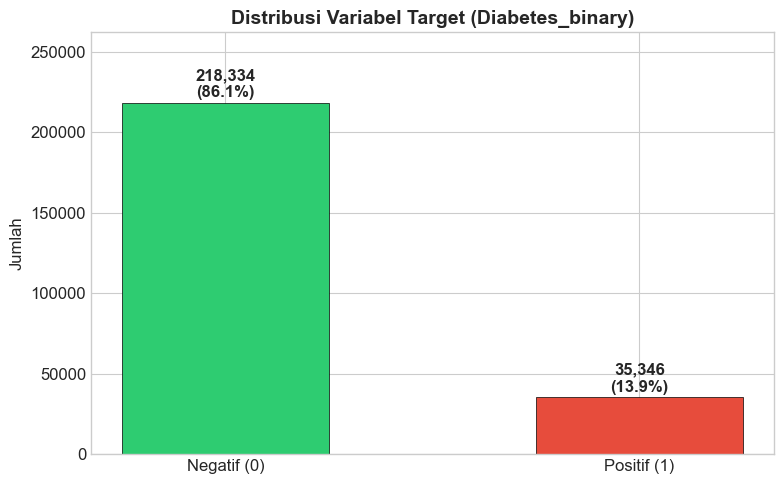

In [9]:
# Visualisasi distribusi target
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#2ecc71', '#e74c3c']
bars = ax.bar(['Negatif (0)', 'Positif (1)'], target_counts.values,
              color=colors, edgecolor='black', linewidth=0.5, width=0.5)

for bar, count, pct in zip(bars, target_counts.values, target_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 1500,
            f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_title('Distribusi Variabel Target (Diabetes_binary)')
ax.set_ylabel('Jumlah')
ax.set_ylim(0, target_counts.max() * 1.2)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**1.3 Analisis Distribusi Fitur**

In [10]:
# Identifikasi tipe fitur
feature_cols = [col for col in df.columns if col != 'Diabetes_binary']

binary_features = [col for col in feature_cols if df[col].nunique() == 2]
ordinal_features = [col for col in feature_cols
                    if df[col].nunique() > 2 and col not in ['BMI', 'MentHlth', 'PhysHlth']]
continuous_features = ['BMI', 'MentHlth', 'PhysHlth']

print(f'Fitur Biner    ({len(binary_features)}): {binary_features}')
print(f'Fitur Ordinal  ({len(ordinal_features)}): {ordinal_features}')
print(f'Fitur Kontinu  ({len(continuous_features)}): {continuous_features}')

Fitur Biner    (14): ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']
Fitur Ordinal  (4): ['GenHlth', 'Age', 'Education', 'Income']
Fitur Kontinu  (3): ['BMI', 'MentHlth', 'PhysHlth']


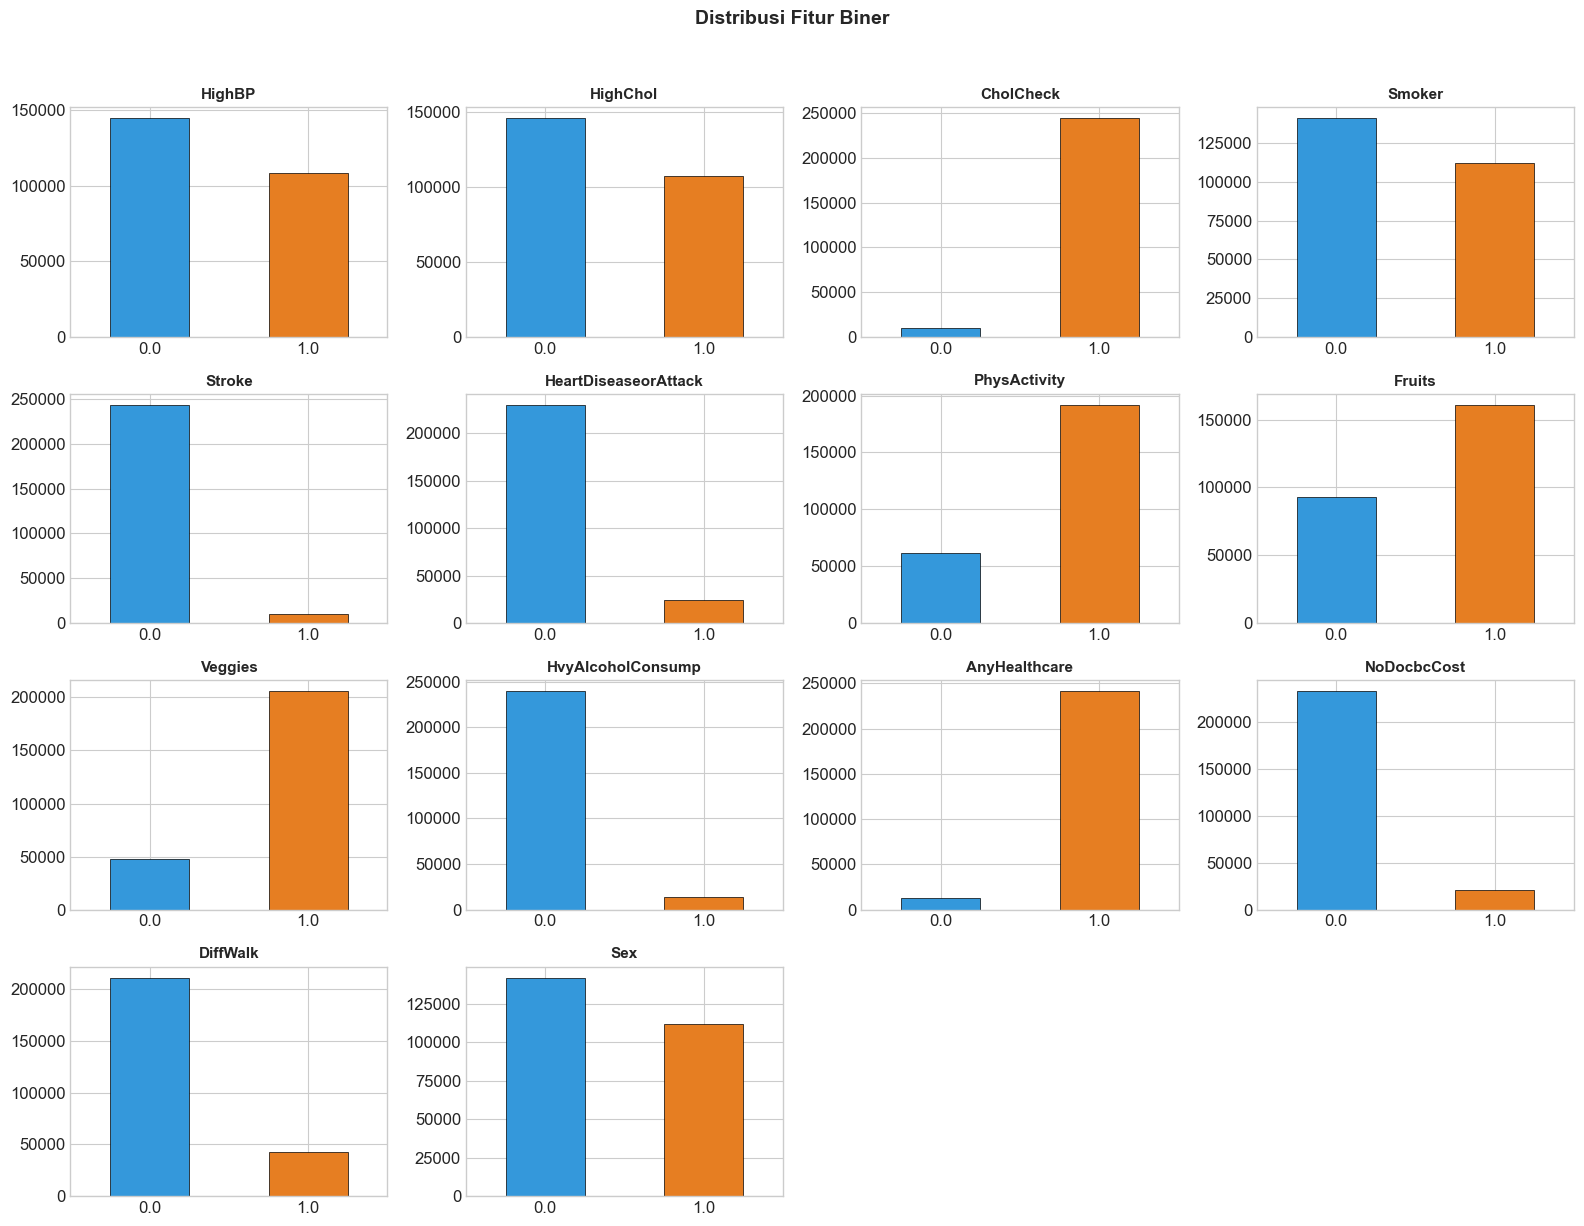

In [11]:
# Histogram fitur biner
n_cols = 4
n_rows = (len(binary_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(binary_features):
    df[col].value_counts().sort_index().plot(kind='bar', ax=axes[i],
                                             color=['#3498db', '#e67e22'],
                                             edgecolor='black', linewidth=0.5)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=0)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribusi Fitur Biner', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}02_binary_features_dist.png', dpi=150, bbox_inches='tight')
plt.show()

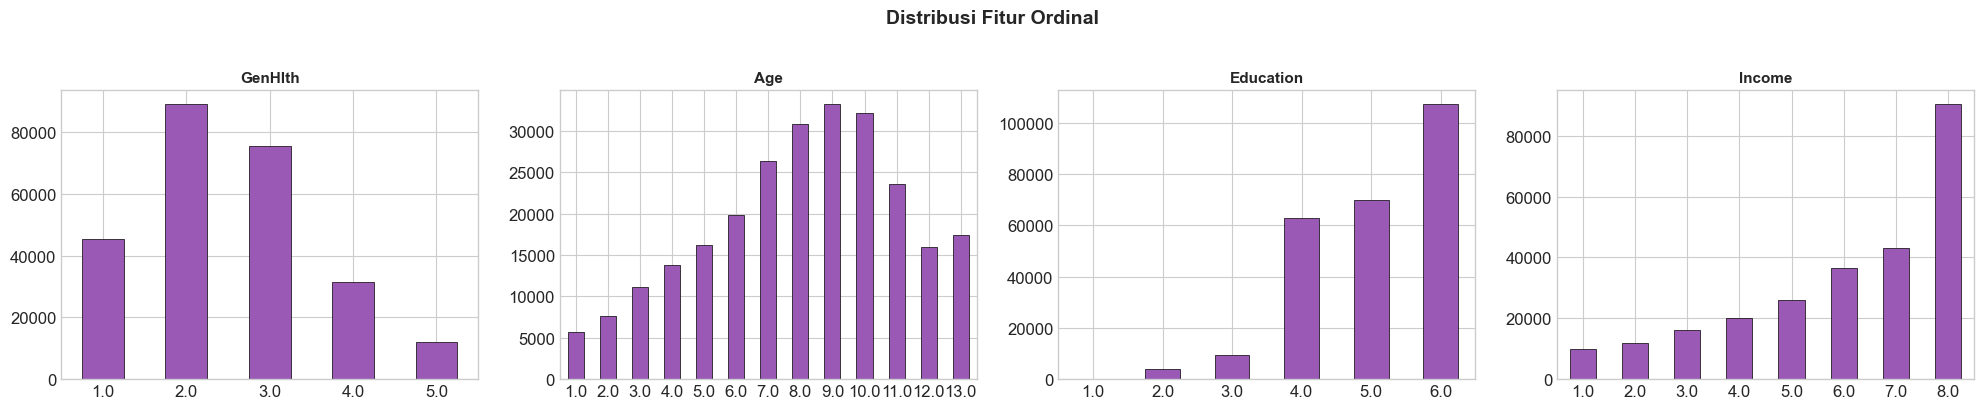

In [12]:
# Histogram fitur ordinal
fig, axes = plt.subplots(1, len(ordinal_features), figsize=(5 * len(ordinal_features), 4))
if len(ordinal_features) == 1:
    axes = [axes]

for i, col in enumerate(ordinal_features):
    df[col].value_counts().sort_index().plot(kind='bar', ax=axes[i],
                                             color='#9b59b6', edgecolor='black', linewidth=0.5)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=0)

fig.suptitle('Distribusi Fitur Ordinal', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}03_ordinal_features_dist.png', dpi=150, bbox_inches='tight')
plt.show()

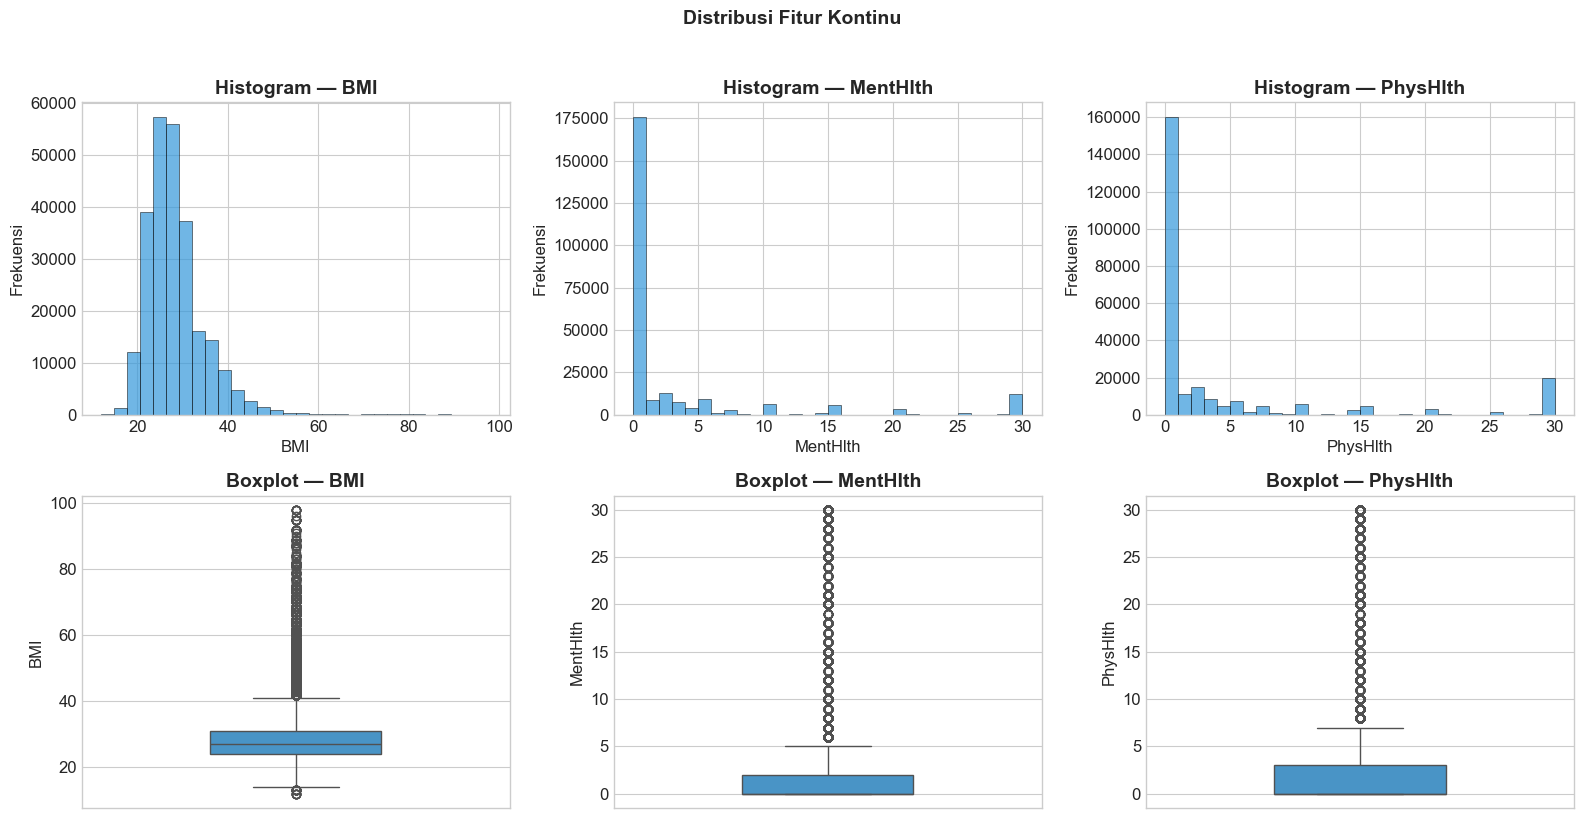

In [13]:
# Histogram & Boxplot fitur kontinu
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for i, col in enumerate(continuous_features):
    # Histogram (baris atas)
    axes[0, i].hist(df[col], bins=30, color='#3498db', edgecolor='black', linewidth=0.5, alpha=0.7)
    axes[0, i].set_title(f'Histogram — {col}')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frekuensi')

    # Boxplot (baris bawah)
    sns.boxplot(data=df, y=col, ax=axes[1, i], color='#3498db', width=0.4)
    axes[1, i].set_title(f'Boxplot — {col}')

fig.suptitle('Distribusi Fitur Kontinu', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}04_continuous_features_dist.png', dpi=150, bbox_inches='tight')
plt.show()

**1.4 Analisis Korelasi**

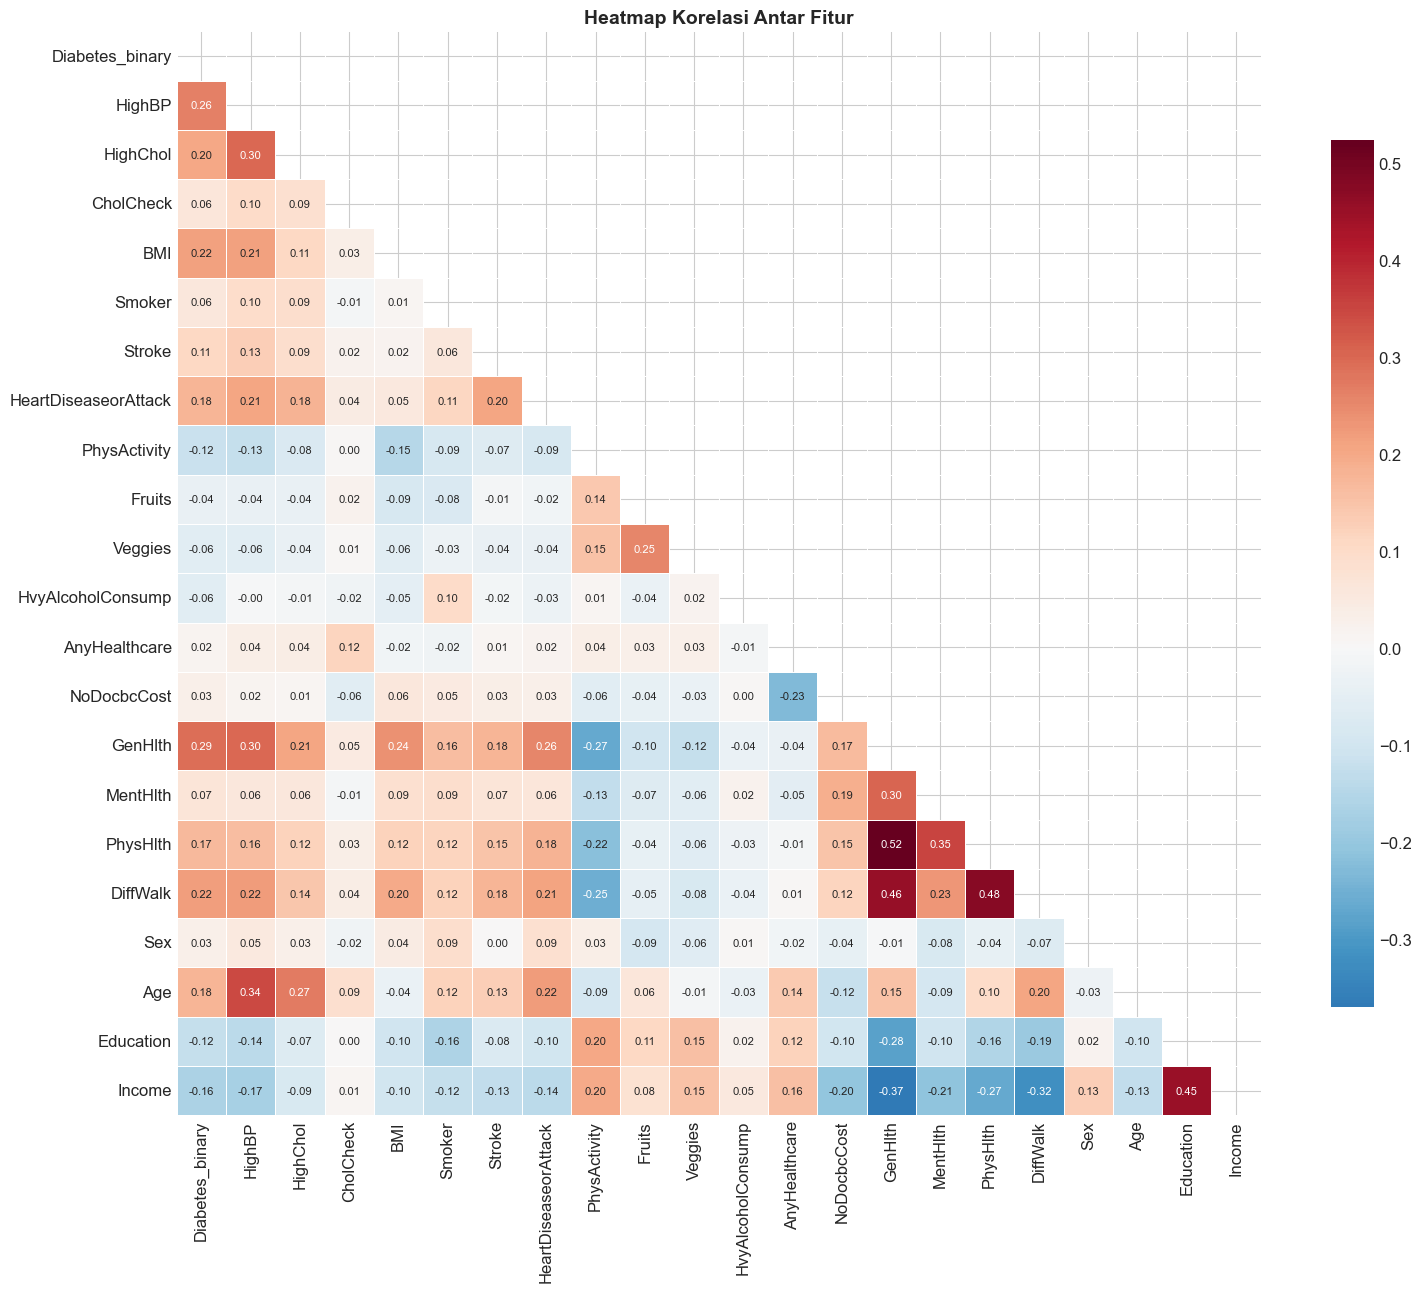


Pasangan fitur dengan korelasi tinggi (|r| > 0.5):
  GenHlth ↔ PhysHlth : r = 0.524


In [14]:
# Heatmap korelasi antar fitur
plt.figure(figsize=(16, 13))

corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 8})

plt.title('Heatmap Korelasi Antar Fitur')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Identifikasi korelasi tinggi (multikolinearitas)
print('\nPasangan fitur dengan korelasi tinggi (|r| > 0.5):')
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.5:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    for f1, f2, r in high_corr_pairs:
        print(f'  {f1} ↔ {f2} : r = {r:.3f}')
else:
    print('  Tidak ditemukan pasangan fitur dengan korelasi > 0.5')

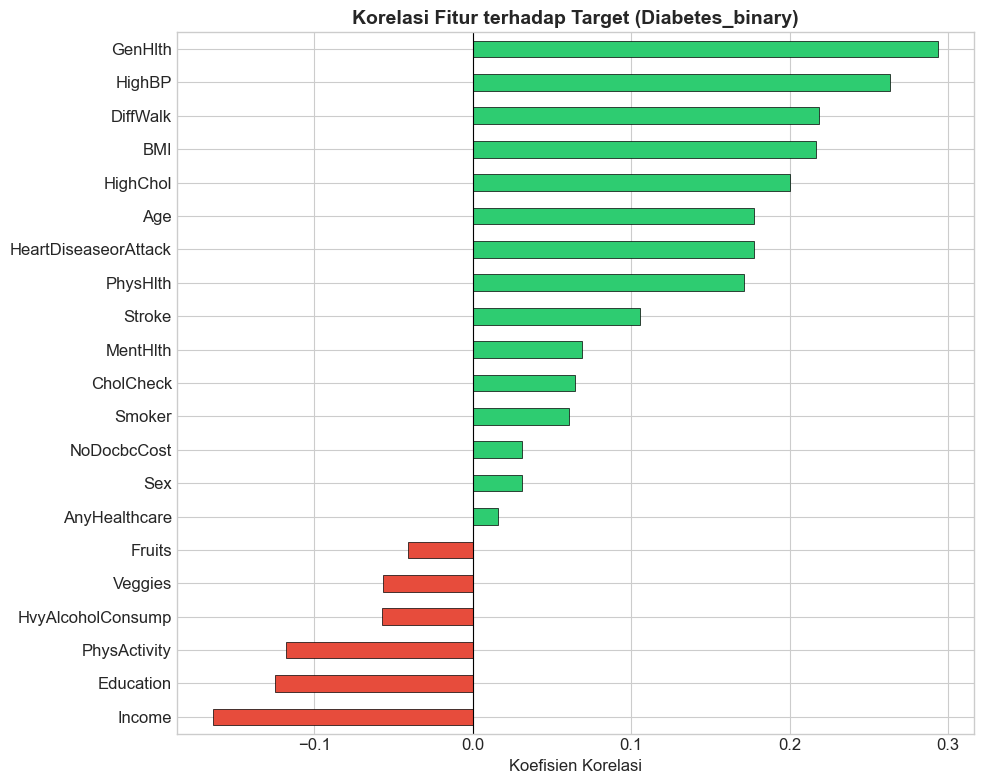


Top 5 fitur dengan korelasi tertinggi terhadap target:
  GenHlth: 0.2936
  HighBP: 0.2631
  DiffWalk: 0.2183
  BMI: 0.2168
  HighChol: 0.2003


In [15]:
# Korelasi setiap fitur terhadap target
corr_target = corr_matrix['Diabetes_binary'].drop('Diabetes_binary').sort_values(ascending=True)

plt.figure(figsize=(10, 8))
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in corr_target.values]
corr_target.plot(kind='barh', color=colors, edgecolor='black', linewidth=0.5)

plt.title('Korelasi Fitur terhadap Target (Diabetes_binary)')
plt.xlabel('Koefisien Korelasi')
plt.axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}06_correlation_with_target.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 fitur dengan korelasi tertinggi terhadap target:')
for feat, val in corr_target.abs().sort_values(ascending=False).head(5).items():
    print(f'  {feat}: {corr_matrix.loc[feat, "Diabetes_binary"]:.4f}')

---
### 2. Data Selection 

**2.1 Perhitungan Mutual Information Score**

In [ ]:
# Pisahkan fitur dan target
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

# Hitung Mutual Information score
mi_scores = mutual_info_classif(X, y, random_state=RANDOM_STATE)

# Buat dataframe ranking
mi_df = pd.DataFrame({
    'Feature': X.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False).reset_index(drop=True)

print('=== Ranking Fitur berdasarkan Mutual Information ===\n')
for idx, row in mi_df.iterrows():
    bar = '█' * int(row['MI_Score'] * 200)
    print(f"  {idx+1:2d}. {row['Feature']:<22s} {row['MI_Score']:.4f}  {bar}")

=== Ranking Fitur berdasarkan Mutual Information ===

   1. HighBP                 0.0531  ██████████
   2. GenHlth                0.0525  ██████████
   3. PhysActivity           0.0524  ██████████
   4. AnyHealthcare          0.0506  ██████████
   5. CholCheck              0.0488  █████████
   6. Fruits                 0.0423  ████████
   7. Veggies                0.0422  ████████
   8. HighChol               0.0407  ████████
   9. BMI                    0.0308  ██████
  10. Sex                    0.0257  █████
  11. Smoker                 0.0247  ████
  12. Age                    0.0236  ████
  13. Education              0.0234  ████
  14. DiffWalk               0.0227  ████
  15. Income                 0.0214  ████
  16. HeartDiseaseorAttack   0.0142  ██
  17. PhysHlth               0.0142  ██
  18. Stroke                 0.0043  
  19. MentHlth               0.0042  
  20. HvyAlcoholConsump      0.0027  
  21. NoDocbcCost            0.0002  


**2.2 Visualisasi Ranking Fitur**

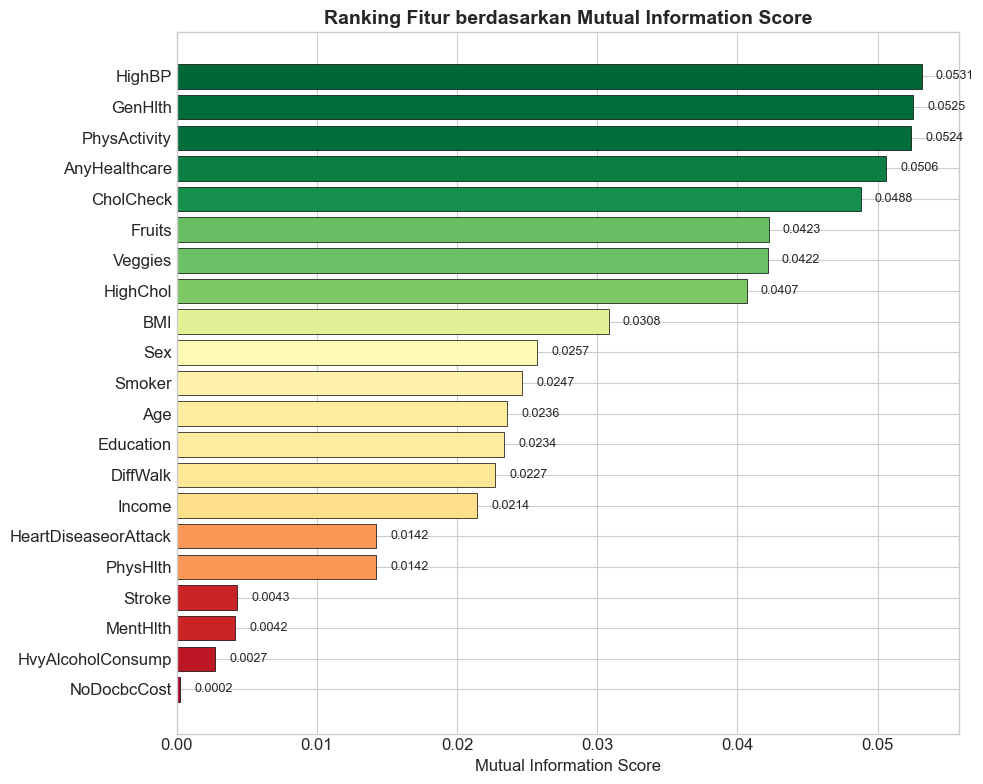

In [ ]:
# Bar chart horizontal — Ranking fitur berdasarkan MI Score
fig, ax = plt.subplots(figsize=(10, 8))

# Urutkan ascending untuk barh (atas = tertinggi)
mi_sorted = mi_df.sort_values('MI_Score', ascending=True)

# Colormap berdasarkan skor
norm = plt.Normalize(mi_sorted['MI_Score'].min(), mi_sorted['MI_Score'].max())
colors = plt.cm.RdYlGn(norm(mi_sorted['MI_Score'].values))

bars = ax.barh(mi_sorted['Feature'], mi_sorted['MI_Score'],
               color=colors, edgecolor='black', linewidth=0.5)

# Tambahkan label nilai
for bar, score in zip(bars, mi_sorted['MI_Score']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{score:.4f}', va='center', fontsize=9)

ax.set_title('Ranking Fitur berdasarkan Mutual Information Score')
ax.set_xlabel('Mutual Information Score')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}07_mi_feature_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

**2.3 Penentuan Threshold & Seleksi Fitur**

In [ ]:
# Tentukan threshold: fitur dengan MI Score > 0.01 dianggap relevan
MI_THRESHOLD = 0.01

selected_features = mi_df[mi_df['MI_Score'] > MI_THRESHOLD]['Feature'].tolist()
eliminated_features = mi_df[mi_df['MI_Score'] <= MI_THRESHOLD]['Feature'].tolist()

print(f'Threshold MI Score: {MI_THRESHOLD}')
print(f'\n{"=" * 50}')
print(f'FITUR TERPILIH ({len(selected_features)} dari {len(mi_df)} fitur):')
print(f'{"=" * 50}')
for f in selected_features:
    score = mi_df[mi_df['Feature'] == f]['MI_Score'].values[0]
    print(f'  ✓ {f:<22s} (MI = {score:.4f})')

if eliminated_features:
    print(f'\n{"=" * 50}')
    print(f'FITUR DIELIMINASI ({len(eliminated_features)} fitur):')
    print(f'{"=" * 50}')
    for f in eliminated_features:
        score = mi_df[mi_df['Feature'] == f]['MI_Score'].values[0]
        print(f'  ✗ {f:<22s} (MI = {score:.4f})')
    print(f'\n>> Fitur dieliminasi karena MI Score ≤ {MI_THRESHOLD} (kontribusi informasi terlalu kecil).')
else:
    print(f'\n>> Semua fitur memiliki MI Score > {MI_THRESHOLD}, tidak ada yang dieliminasi.')

Threshold MI Score: 0.01

FITUR TERPILIH (17 dari 21 fitur):
  ✓ HighBP                 (MI = 0.0531)
  ✓ GenHlth                (MI = 0.0525)
  ✓ PhysActivity           (MI = 0.0524)
  ✓ AnyHealthcare          (MI = 0.0506)
  ✓ CholCheck              (MI = 0.0488)
  ✓ Fruits                 (MI = 0.0423)
  ✓ Veggies                (MI = 0.0422)
  ✓ HighChol               (MI = 0.0407)
  ✓ BMI                    (MI = 0.0308)
  ✓ Sex                    (MI = 0.0257)
  ✓ Smoker                 (MI = 0.0247)
  ✓ Age                    (MI = 0.0236)
  ✓ Education              (MI = 0.0234)
  ✓ DiffWalk               (MI = 0.0227)
  ✓ Income                 (MI = 0.0214)
  ✓ HeartDiseaseorAttack   (MI = 0.0142)
  ✓ PhysHlth               (MI = 0.0142)

FITUR DIELIMINASI (4 fitur):
  ✗ Stroke                 (MI = 0.0043)
  ✗ MentHlth               (MI = 0.0042)
  ✗ HvyAlcoholConsump      (MI = 0.0027)
  ✗ NoDocbcCost            (MI = 0.0002)

>> Fitur dieliminasi karena MI Score ≤ 0.01 (ko

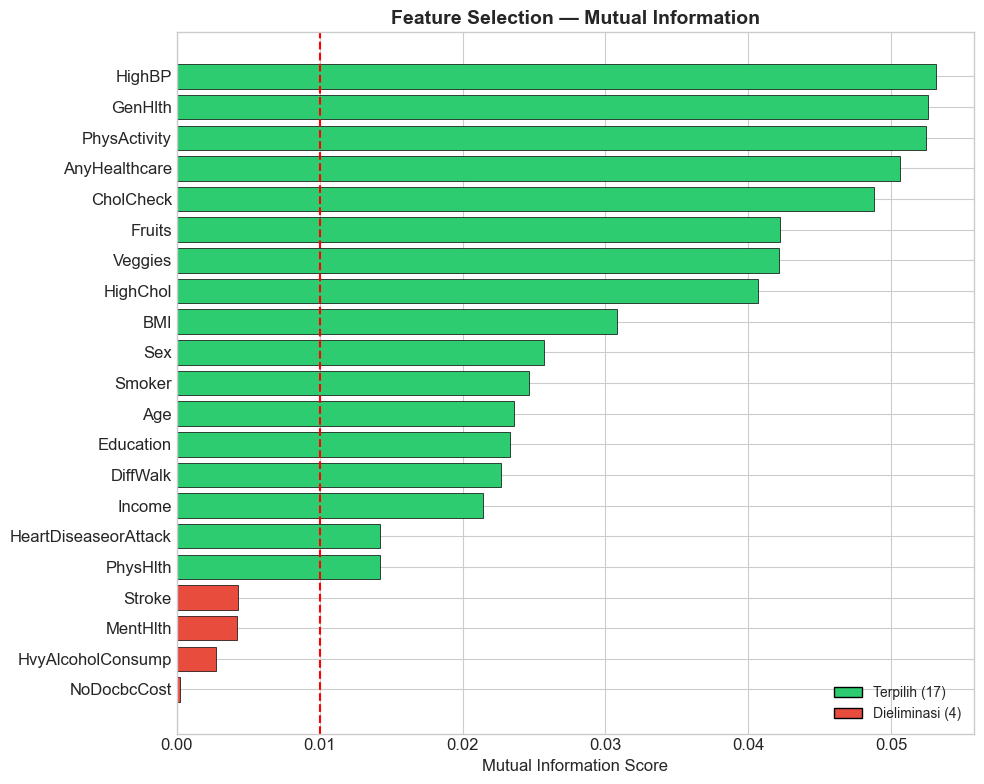


>> 17 fitur akan digunakan pada tahap selanjutnya.


In [ ]:
# Visualisasi threshold pada bar chart
fig, ax = plt.subplots(figsize=(10, 8))

mi_sorted = mi_df.sort_values('MI_Score', ascending=True)
bar_colors = ['#2ecc71' if score > MI_THRESHOLD else '#e74c3c'
              for score in mi_sorted['MI_Score']]

ax.barh(mi_sorted['Feature'], mi_sorted['MI_Score'],
        color=bar_colors, edgecolor='black', linewidth=0.5)

ax.axvline(x=MI_THRESHOLD, color='red', linestyle='--', linewidth=1.5,
           label=f'Threshold = {MI_THRESHOLD}')

ax.set_title('Feature Selection — Mutual Information')
ax.set_xlabel('Mutual Information Score')
ax.legend(loc='lower right', fontsize=11)

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', edgecolor='black', label=f'Terpilih ({len(selected_features)})'),
    Patch(facecolor='#e74c3c', edgecolor='black', label=f'Dieliminasi ({len(eliminated_features)})'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}08_feature_selection_result.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n>> {len(selected_features)} fitur akan digunakan pada tahap selanjutnya.')

---
### 3. Preprocessing



**3.1 Pengecekan Missing Values**

In [20]:
# Cek missing values per kolom
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
})

print('=== Pengecekan Missing Values ===')
print(f'Total missing values: {missing.sum()}')

if missing.sum() > 0:
    print('\nKolom dengan missing values:')
    print(missing_report[missing_report['Missing Count'] > 0])
else:
    print('\n>> Tidak ditemukan missing values pada dataset.')

=== Pengecekan Missing Values ===
Total missing values: 0

>> Tidak ditemukan missing values pada dataset.


**3.2 Pengecekan Data Duplikat**

In [21]:
# Cek data duplikat
duplicates = df.duplicated().sum()
dup_pct = (duplicates / len(df)) * 100

print('=== Pengecekan Data Duplikat ===')
print(f'Jumlah data duplikat : {duplicates:,}')
print(f'Persentase duplikat  : {dup_pct:.2f}%')

if duplicates > 0:
    print(f'\n>> Ditemukan {duplicates:,} baris duplikat ({dup_pct:.2f}%).')
    print('>> Note: Data duplikat akan dihapus untuk menghindari bias pada model.')

    df_clean = df.drop_duplicates().reset_index(drop=True)
    print(f'\nData sebelum  : {len(df):,} baris')
    print(f'Data sesudah  : {len(df_clean):,} baris')
    print(f'Data dihapus  : {len(df) - len(df_clean):,} baris')
else:
    df_clean = df.copy()
    print('\n>> Tidak ditemukan data duplikat.')

=== Pengecekan Data Duplikat ===
Jumlah data duplikat : 24,206
Persentase duplikat  : 9.54%

>> Ditemukan 24,206 baris duplikat (9.54%).
>> Note: Data duplikat akan dihapus untuk menghindari bias pada model.

Data sebelum  : 253,680 baris
Data sesudah  : 229,474 baris
Data dihapus  : 24,206 baris


**3.3 Handling Imbalanced Class — Random Undersampling**

In [22]:
# Distribusi sebelum undersampling
class_0 = df_clean[df_clean['Diabetes_binary'] == 0]
class_1 = df_clean[df_clean['Diabetes_binary'] == 1]

print('=== Distribusi Kelas Sebelum Undersampling ===')
print(f'  Kelas 0 (Negatif): {len(class_0):,}')
print(f'  Kelas 1 (Positif): {len(class_1):,}')
print(f'  Total            : {len(df_clean):,}')
print(f'  Rasio            : 1 : {len(class_0) / len(class_1):.2f}')

=== Distribusi Kelas Sebelum Undersampling ===
  Kelas 0 (Negatif): 194,377
  Kelas 1 (Positif): 35,097
  Total            : 229,474
  Rasio            : 1 : 5.54


In [23]:
# Random undersampling kelas mayoritas
class_0_undersampled = class_0.sample(n=len(class_1), random_state=RANDOM_STATE)

# Gabungkan dan acak urutan
df_balanced = pd.concat([class_0_undersampled, class_1]) \
                .sample(frac=1, random_state=RANDOM_STATE) \
                .reset_index(drop=True)

print('=== Distribusi Kelas Setelah Undersampling ===')
bal_counts = df_balanced['Diabetes_binary'].value_counts().sort_index()
bal_pct = df_balanced['Diabetes_binary'].value_counts(normalize=True).sort_index() * 100

print(f'  Kelas 0 (Negatif): {bal_counts[0]:,} ({bal_pct[0]:.1f}%)')
print(f'  Kelas 1 (Positif): {bal_counts[1]:,} ({bal_pct[1]:.1f}%)')
print(f'  Total            : {len(df_balanced):,}')
print(f'  Rasio            : 1 : {bal_counts[0] / bal_counts[1]:.2f}')

=== Distribusi Kelas Setelah Undersampling ===
  Kelas 0 (Negatif): 35,097 (50.0%)
  Kelas 1 (Positif): 35,097 (50.0%)
  Total            : 70,194
  Rasio            : 1 : 1.00


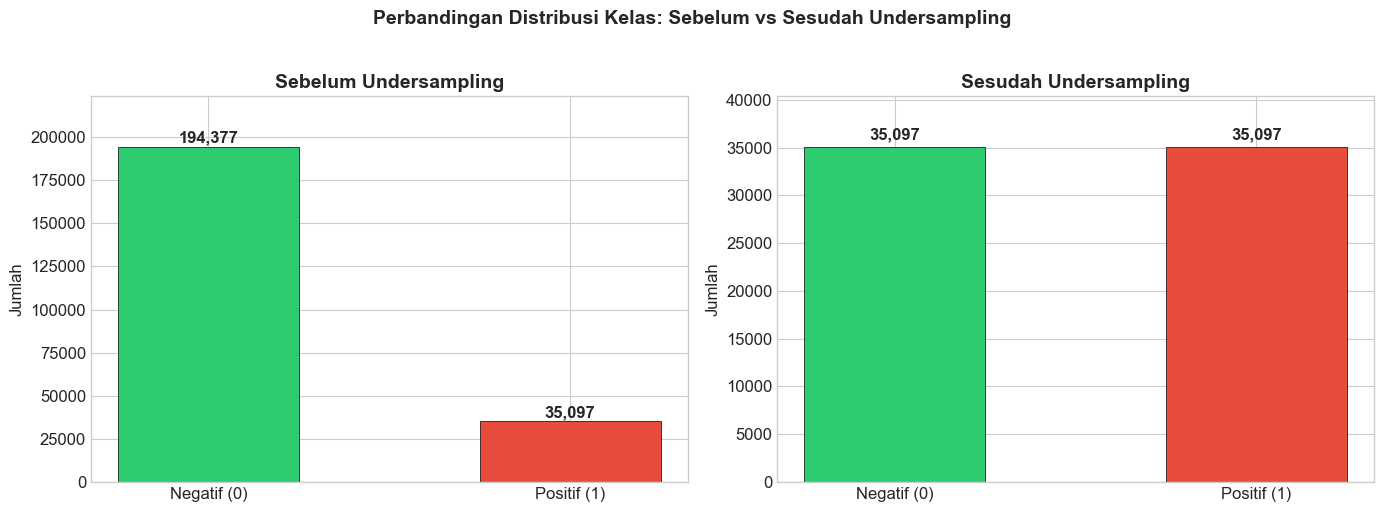

In [24]:
# Visualisasi perbandingan sebelum vs sesudah undersampling
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sebelum
labels = ['Negatif (0)', 'Positif (1)']
colors = ['#2ecc71', '#e74c3c']

before_counts = [len(class_0), len(class_1)]
bars1 = axes[0].bar(labels, before_counts, color=colors, edgecolor='black', linewidth=0.5, width=0.5)
for bar, count in zip(bars1, before_counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 500,
                 f'{count:,}', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Sebelum Undersampling')
axes[0].set_ylabel('Jumlah')
axes[0].set_ylim(0, max(before_counts) * 1.15)

# Sesudah
after_counts = [bal_counts[0], bal_counts[1]]
bars2 = axes[1].bar(labels, after_counts, color=colors, edgecolor='black', linewidth=0.5, width=0.5)
for bar, count in zip(bars2, after_counts):
    axes[1].text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 500,
                 f'{count:,}', ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Sesudah Undersampling')
axes[1].set_ylabel('Jumlah')
axes[1].set_ylim(0, max(after_counts) * 1.15)

fig.suptitle('Perbandingan Distribusi Kelas: Sebelum vs Sesudah Undersampling',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}09_undersampling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# Simpan dataset yang sudah balanced
df_balanced.to_csv(f'{PROCESSED_DIR}data_balanced.csv', index=False)

print(f'Dataset balanced disimpan ke: {PROCESSED_DIR}data_balanced.csv')
print(f'Ukuran: {len(df_balanced):,} baris × {df_balanced.shape[1]} kolom')

Dataset balanced disimpan ke: ../data/processed/data_balanced.csv
Ukuran: 70,194 baris × 22 kolom


---
### 4. Transformation

**4.1 Persiapan Data dengan Fitur Terpilih**

In [26]:
# Gunakan hanya fitur yang terpilih dari feature selection
X_balanced = df_balanced[selected_features]
y_balanced = df_balanced['Diabetes_binary']

print(f'Jumlah fitur terpilih: {len(selected_features)}')
print(f'Fitur: {selected_features}')
print(f'\nDimensi X: {X_balanced.shape}')
print(f'Dimensi y: {y_balanced.shape}')

Jumlah fitur terpilih: 17
Fitur: ['HighBP', 'GenHlth', 'PhysActivity', 'AnyHealthcare', 'CholCheck', 'Fruits', 'Veggies', 'HighChol', 'BMI', 'Sex', 'Smoker', 'Age', 'Education', 'DiffWalk', 'Income', 'HeartDiseaseorAttack', 'PhysHlth']

Dimensi X: (70194, 17)
Dimensi y: (70194,)


**4.2 Train / Test Split (80:20)**

In [27]:
# Stratified split 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_balanced
)

print('=== Hasil Train/Test Split (80:20) ===')
print(f'\nData Training:')
print(f'  X_train : {X_train.shape}')
print(f'  y_train : {y_train.shape}')
print(f'  Kelas 0 : {(y_train == 0).sum():,} ({(y_train == 0).mean() * 100:.1f}%)')
print(f'  Kelas 1 : {(y_train == 1).sum():,} ({(y_train == 1).mean() * 100:.1f}%)')

print(f'\nData Testing:')
print(f'  X_test  : {X_test.shape}')
print(f'  y_test  : {y_test.shape}')
print(f'  Kelas 0 : {(y_test == 0).sum():,} ({(y_test == 0).mean() * 100:.1f}%)')
print(f'  Kelas 1 : {(y_test == 1).sum():,} ({(y_test == 1).mean() * 100:.1f}%)')

=== Hasil Train/Test Split (80:20) ===

Data Training:
  X_train : (56155, 17)
  y_train : (56155,)
  Kelas 0 : 28,077 (50.0%)
  Kelas 1 : 28,078 (50.0%)

Data Testing:
  X_test  : (14039, 17)
  y_test  : (14039,)
  Kelas 0 : 7,020 (50.0%)
  Kelas 1 : 7,019 (50.0%)


**4.3 Standarisasi Fitur — StandardScaler**

> **Penting:** `StandardScaler` hanya di-`fit` pada data training, lalu di-`transform` pada data training DAN testing secara terpisah untuk mencegah **data leakage**.

In [28]:
# Standarisasi
scaler = StandardScaler()

# Fit HANYA pada data training
X_train_scaled = scaler.fit_transform(X_train)

# Transform data testing (menggunakan parameter dari training)
X_test_scaled = scaler.transform(X_test)

print('=== Standarisasi Selesai ===')
print(f'\nStatistik X_train_scaled:')
print(f'  Mean (harus ≈ 0) : {X_train_scaled.mean(axis=0).round(6)}')
print(f'  Std  (harus ≈ 1) : {X_train_scaled.std(axis=0).round(4)}')

print(f'\nStatistik X_test_scaled:')
print(f'  Mean : {X_test_scaled.mean(axis=0).round(4)}')
print(f'  Std  : {X_test_scaled.std(axis=0).round(4)}')

=== Standarisasi Selesai ===

Statistik X_train_scaled:
  Mean (harus ≈ 0) : [ 0.  0. -0.  0.  0.  0. -0.  0.  0. -0.  0. -0. -0. -0. -0. -0. -0.]
  Std  (harus ≈ 1) : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Statistik X_test_scaled:
  Mean : [-0.0121  0.0013 -0.0075  0.0105  0.0009  0.012  -0.0061  0.012   0.0122
  0.0055 -0.0134 -0.0011  0.0049 -0.0049  0.018  -0.0076  0.0046]
  Std  : [1.0018 1.0027 1.0031 0.9777 0.9973 0.9975 1.004  0.9991 1.0188 1.0005
 0.9996 0.9973 1.0076 0.9974 0.9924 0.9926 1.0096]


**4.4 Verifikasi Dimensi & Distribusi**

In [29]:
# Ringkasan akhir transformasi
print('=' * 55)
print('RINGKASAN TRANSFORMASI DATA')
print('=' * 55)
print(f'  Jumlah fitur        : {len(selected_features)}')
print(f'  Split rasio         : 80% train / 20% test')
print(f'  Scaler              : StandardScaler')
print(f'  Random state        : {RANDOM_STATE}')
print(f'  Stratified          : Ya')
print(f'\n  X_train_scaled      : {X_train_scaled.shape}')
print(f'  X_test_scaled       : {X_test_scaled.shape}')
print(f'  y_train             : {y_train.shape}')
print(f'  y_test              : {y_test.shape}')
print(f'\n>> Data siap untuk tahap Data Mining (Pemodelan).')

RINGKASAN TRANSFORMASI DATA
  Jumlah fitur        : 17
  Split rasio         : 80% train / 20% test
  Scaler              : StandardScaler
  Random state        : 42
  Stratified          : Ya

  X_train_scaled      : (56155, 17)
  X_test_scaled       : (14039, 17)
  y_train             : (56155,)
  y_test              : (14039,)

>> Data siap untuk tahap Data Mining (Pemodelan).


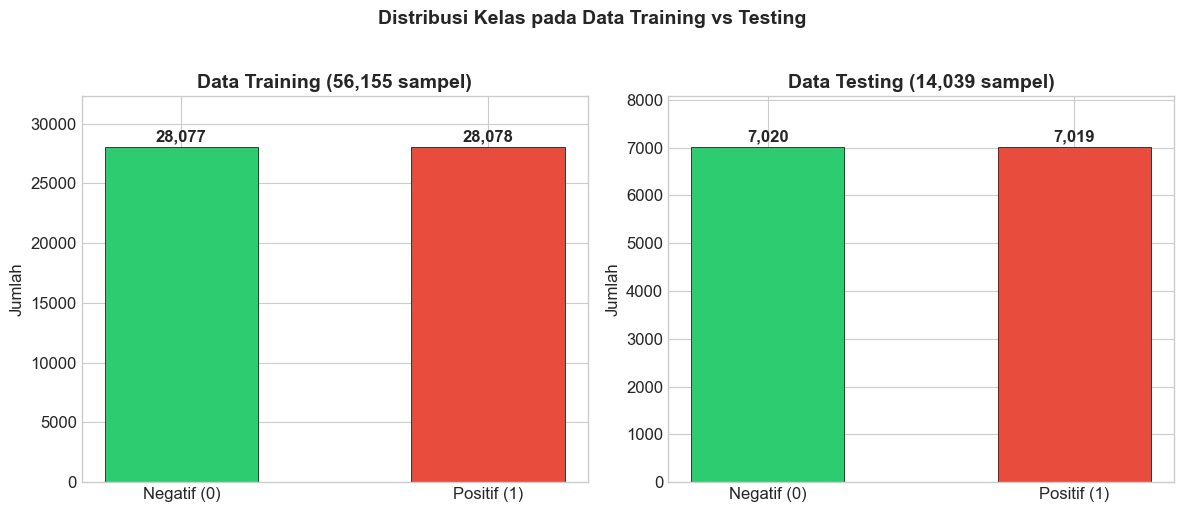

In [30]:
# Visualisasi distribusi kelas pada train vs test
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ['Negatif (0)', 'Positif (1)']
colors = ['#2ecc71', '#e74c3c']

# Training
train_counts = [int((y_train == 0).sum()), int((y_train == 1).sum())]
bars1 = axes[0].bar(labels, train_counts, color=colors, edgecolor='black', linewidth=0.5, width=0.5)
for bar, count in zip(bars1, train_counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 200,
                 f'{count:,}', ha='center', va='bottom', fontweight='bold')
axes[0].set_title(f'Data Training ({len(y_train):,} sampel)')
axes[0].set_ylabel('Jumlah')
axes[0].set_ylim(0, max(train_counts) * 1.15)

# Testing
test_counts = [int((y_test == 0).sum()), int((y_test == 1).sum())]
bars2 = axes[1].bar(labels, test_counts, color=colors, edgecolor='black', linewidth=0.5, width=0.5)
for bar, count in zip(bars2, test_counts):
    axes[1].text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 50,
                 f'{count:,}', ha='center', va='bottom', fontweight='bold')
axes[1].set_title(f'Data Testing ({len(y_test):,} sampel)')
axes[1].set_ylabel('Jumlah')
axes[1].set_ylim(0, max(test_counts) * 1.15)

fig.suptitle('Distribusi Kelas pada Data Training vs Testing',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}10_train_test_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# Simpan data final
df_train_final = pd.DataFrame(X_train_scaled, columns=selected_features)
df_train_final['Diabetes_binary'] = y_train.values

df_test_final = pd.DataFrame(X_test_scaled, columns=selected_features)
df_test_final['Diabetes_binary'] = y_test.values

df_train_final.to_csv(f'{PROCESSED_DIR}data_final_train.csv', index=False)
df_test_final.to_csv(f'{PROCESSED_DIR}data_final_test.csv', index=False)

print(f'Data training disimpan: {PROCESSED_DIR}data_final_train.csv ({len(df_train_final):,} baris)')
print(f'Data testing disimpan : {PROCESSED_DIR}data_final_test.csv ({len(df_test_final):,} baris)')

Data training disimpan: ../data/processed/data_final_train.csv (56,155 baris)
Data testing disimpan : ../data/processed/data_final_test.csv (14,039 baris)


---
### 5. Data Mining

#### 5.1 Model SVM + Grid Search

**5.1.1 Definisi Search Space**

In [ ]:
# Definisi grid parameter
param_grid = {
    'C'     : [0.1, 1, 10, 100],
    'gamma' : [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear']
}

# Hitung total kombinasi
total_combinations = 1
for key, values in param_grid.items():
    total_combinations *= len(values)

print('=== Grid Search — Search Space ===')
for key, values in param_grid.items():
    print(f'  {key:8s}: {values}')
print(f'\n  Total kombinasi     : {total_combinations}')
print(f'  Cross-validation    : 5-fold')
print(f'  Total fit yang akan dilakukan: {total_combinations * 5}')
print(f'  Scoring             : F1-Score')

**5.2.2 Pelaksanaan Grid Search**

In [ ]:
# Inisialisasi SVM
svm_gs = SVC(random_state=RANDOM_STATE, probability=True)

# Grid Search dengan 5-fold CV
grid_search = GridSearchCV(
    estimator=svm_gs,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# Eksekusi dan catat waktu
print('Memulai Grid Search...\n')
gs_start_time = time.time()
grid_search.fit(X_train_scaled, y_train)
gs_time = time.time() - gs_start_time

print(f'\n{"=" * 50}')
print(f'Grid Search selesai dalam {gs_time:.2f} detik ({gs_time / 60:.2f} menit)')
print(f'{"=" * 50}')

**5.2.3 Hasil Grid Search**

In [ ]:
# Hasil terbaik
print('=== Hasil Grid Search ===')
print(f'\nBest Parameters:')
for key, value in grid_search.best_params_.items():
    print(f'  {key:8s}: {value}')

print(f'\nBest CV F1-Score : {grid_search.best_score_:.4f}')
print(f'Waktu Komputasi  : {gs_time:.2f} detik')

# Model terbaik
model_gs = grid_search.best_estimator_
print(f'\nModel: {model_gs}')

In [ ]:
# Top 10 kombinasi parameter
cv_results = pd.DataFrame(grid_search.cv_results_)
top10 = cv_results.nsmallest(10, 'rank_test_score')[[
    'rank_test_score', 'params', 'mean_test_score',
    'std_test_score', 'mean_train_score'
]].reset_index(drop=True)

print('=== Top 10 Kombinasi Parameter ===')
for idx, row in top10.iterrows():
    print(f"  #{row['rank_test_score']:2.0f} | "
          f"F1={row['mean_test_score']:.4f} ± {row['std_test_score']:.4f} | "
          f"{row['params']}")

#### 5.2 Model SVM + PSO (Particle Swarm Optimization)

**5.2.1 Definisi Search Space & Fungsi Fitness**

In [ ]:
# ============================================================
# SEARCH SPACE (dalam skala log10)
# ============================================================
# C     : 10^(-3) sampai 10^(3)  → [0.001, 1000]
# gamma : 10^(-4) sampai 10^(1)  → [0.0001, 10]

PSO_BOUNDS = {
    'lower': np.array([-3, -4]),   # [log10(C_min), log10(gamma_min)]
    'upper': np.array([3, 1])      # [log10(C_max), log10(gamma_max)]
}

print('=== PSO — Search Space ===')
print(f'  C     : [10^{PSO_BOUNDS["lower"][0]:.0f}, 10^{PSO_BOUNDS["upper"][0]:.0f}] → [{10**PSO_BOUNDS["lower"][0]}, {10**PSO_BOUNDS["upper"][0]}]')
print(f'  gamma : [10^{PSO_BOUNDS["lower"][1]:.0f}, 10^{PSO_BOUNDS["upper"][1]:.0f}] → [{10**PSO_BOUNDS["lower"][1]}, {10**PSO_BOUNDS["upper"][1]}]')
print(f'  Skala : Logaritmik (base 10)')

In [ ]:
# ============================================================
# FUNGSI FITNESS
# ============================================================
def pso_fitness(particles, X_train, y_train, cv=5):
    """
    Evaluasi fitness untuk semua partikel.
    Fitness = negative mean CV F1-Score (karena PSO meminimasi).
    
    Parameters:
        particles : array shape (n_particles, 2) — [log10(C), log10(gamma)]
        X_train   : data training (scaled)
        y_train   : label training
        cv        : jumlah fold cross-validation
    
    Returns:
        scores : array shape (n_particles,) — negative F1-Score
    """
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    
    for particle in particles:
        C = 10 ** particle[0]
        gamma = 10 ** particle[1]
        
        svm = SVC(C=C, gamma=gamma, kernel='rbf', random_state=RANDOM_STATE)
        cv_scores = cross_val_score(svm, X_train, y_train, cv=skf, scoring='f1')
        scores.append(-np.mean(cv_scores))  # negatif karena PSO minimasi
    
    return np.array(scores)

print('Fungsi fitness didefinisikan.')
print('  Input  : posisi partikel [log10(C), log10(gamma)]')
print('  Output : -mean(CV F1-Score) → PSO meminimasi')

**5.2.2 Konfigurasi PSO**

In [ ]:
# ============================================================
# KONFIGURASI PSO
# ============================================================

N_PARTICLES = 20       # Jumlah partikel
N_ITERATIONS = 50      # Iterasi maksimum
DIMENSIONS = 2         # C dan gamma

# Koefisien PSO
W  = 0.7298            # Inersia (inertia weight)
C1 = 1.4962            # Koefisien kognitif (personal best)
C2 = 1.4962            # Koefisien sosial (global best)

# Early stopping
PATIENCE = 10           # Berhenti jika tidak ada improvement selama N iterasi
MIN_IMPROVEMENT = 1e-6  # Threshold minimum improvement

print('=== Konfigurasi PSO ===')
print(f'  Jumlah partikel   : {N_PARTICLES}')
print(f'  Iterasi maksimum  : {N_ITERATIONS}')
print(f'  Dimensi           : {DIMENSIONS} (C, gamma)')
print(f'  Inersia (w)       : {W}')
print(f'  Kognitif (c1)     : {C1}')
print(f'  Sosial (c2)       : {C2}')
print(f'  Early stopping    : {PATIENCE} iterasi tanpa improvement')
print(f'  Min improvement   : {MIN_IMPROVEMENT}')

**5.2.3 Eksekusi PSO**

In [ ]:
# ============================================================
# INISIALISASI PARTIKEL
# ============================================================
lb = PSO_BOUNDS['lower']
ub = PSO_BOUNDS['upper']

# Posisi dan kecepatan awal (random uniform)
positions  = np.random.uniform(lb, ub, (N_PARTICLES, DIMENSIONS))
velocities = np.random.uniform(-1, 1, (N_PARTICLES, DIMENSIONS))

# Evaluasi fitness awal
fitness_values = pso_fitness(positions, X_train_scaled, y_train)

# Personal best
pbest_positions = positions.copy()
pbest_scores    = fitness_values.copy()

# Global best
gbest_idx      = np.argmin(fitness_values)
gbest_position = positions[gbest_idx].copy()
gbest_score    = fitness_values[gbest_idx]

print(f'Inisialisasi selesai.')
print(f'  Global best awal — C: {10**gbest_position[0]:.4f}, gamma: {10**gbest_position[1]:.6f}')
print(f'  F1-Score awal    : {-gbest_score:.4f}')

In [ ]:
# ============================================================
# LOOP UTAMA PSO DENGAN EARLY STOPPING
# ============================================================

convergence_history = [-gbest_score]  # Simpan F1-Score terbaik per iterasi
no_improve_count = 0
stopped_early = False

print(f'Memulai PSO ({N_PARTICLES} partikel, maks {N_ITERATIONS} iterasi)...\n')
print(f'{"Iter":>5s} | {"Best F1":>8s} | {"C":>10s} | {"gamma":>10s} | {"Status"}')
print('-' * 60)

pso_start_time = time.time()

for iteration in range(N_ITERATIONS):
    # --- Update kecepatan ---
    r1 = np.random.random((N_PARTICLES, DIMENSIONS))
    r2 = np.random.random((N_PARTICLES, DIMENSIONS))
    
    cognitive = C1 * r1 * (pbest_positions - positions)
    social    = C2 * r2 * (gbest_position - positions)
    velocities = W * velocities + cognitive + social
    
    # --- Update posisi ---
    positions = positions + velocities
    positions = np.clip(positions, lb, ub)  # Batasi dalam search space
    
    # --- Evaluasi fitness ---
    fitness_values = pso_fitness(positions, X_train_scaled, y_train)
    
    # --- Update personal best ---
    improved_mask = fitness_values < pbest_scores
    pbest_positions[improved_mask] = positions[improved_mask]
    pbest_scores[improved_mask]    = fitness_values[improved_mask]
    
    # --- Update global best ---
    current_best_idx   = np.argmin(pbest_scores)
    current_best_score = pbest_scores[current_best_idx]
    
    if current_best_score < gbest_score - MIN_IMPROVEMENT:
        gbest_score    = current_best_score
        gbest_position = pbest_positions[current_best_idx].copy()
        no_improve_count = 0
        status = '✓ improved'
    else:
        no_improve_count += 1
        status = f'  no improve ({no_improve_count}/{PATIENCE})'
    
    convergence_history.append(-gbest_score)
    
    # Log setiap 5 iterasi atau saat improvement
    if (iteration + 1) % 5 == 0 or 'improved' in status:
        print(f'{iteration+1:5d} | {-gbest_score:8.4f} | '
              f'{10**gbest_position[0]:10.4f} | {10**gbest_position[1]:10.6f} | {status}')
    
    # --- Early stopping ---
    if no_improve_count >= PATIENCE:
        stopped_early = True
        print(f'\n>> EARLY STOPPING pada iterasi {iteration + 1}')
        print(f'>> Tidak ada improvement selama {PATIENCE} iterasi berturut-turut.')
        break

pso_time = time.time() - pso_start_time

print(f'\n{"=" * 60}')
print(f'PSO selesai dalam {pso_time:.2f} detik ({pso_time / 60:.2f} menit)')
print(f'Total iterasi    : {len(convergence_history) - 1} / {N_ITERATIONS}')
print(f'Early stopping   : {"Ya" if stopped_early else "Tidak"}')
print(f'{"=" * 60}')

**5.2.4 Hasil PSO**

In [ ]:
# Hyperparameter terbaik
best_C_pso     = 10 ** gbest_position[0]
best_gamma_pso = 10 ** gbest_position[1]

print('=== Hasil PSO ===')
print(f'\nBest Parameters:')
print(f'  C       : {best_C_pso:.6f}')
print(f'  gamma   : {best_gamma_pso:.6f}')
print(f'  kernel  : rbf')
print(f'\nBest CV F1-Score : {-gbest_score:.4f}')
print(f'Waktu Komputasi  : {pso_time:.2f} detik')
print(f'Total Iterasi    : {len(convergence_history) - 1}')

**5.2.5 Pelatihan Model Akhir & Kurva Konvergensi**

In [ ]:
# Latih model final dengan parameter terbaik PSO
model_pso = SVC(
    C=best_C_pso,
    gamma=best_gamma_pso,
    kernel='rbf',
    random_state=RANDOM_STATE,
    probability=True
)
model_pso.fit(X_train_scaled, y_train)

print(f'Model SVM+PSO berhasil dilatih pada {X_train_scaled.shape[0]:,} sampel training.')
print(f'Model: {model_pso}')

In [ ]:
# Kurva konvergensi PSO
fig, ax = plt.subplots(figsize=(10, 6))

iterations = range(len(convergence_history))
ax.plot(iterations, convergence_history, 'b-o', markersize=4, linewidth=1.5,
        markerfacecolor='white', markeredgecolor='blue', markeredgewidth=1.2)

# Tandai titik early stopping
if stopped_early:
    stop_iter = len(convergence_history) - 1
    ax.axvline(x=stop_iter, color='red', linestyle='--', linewidth=1.2,
               label=f'Early stopping (iter {stop_iter})')

# Tandai best score
best_iter = np.argmax(convergence_history)
ax.scatter(best_iter, convergence_history[best_iter], color='red', s=100,
           zorder=5, label=f'Best F1 = {max(convergence_history):.4f} (iter {best_iter})')

ax.set_title('Kurva Konvergensi PSO')
ax.set_xlabel('Iterasi')
ax.set_ylabel('Best F1-Score (CV)')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}11_pso_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# RINGKASAN PERBANDINGAN KEDUA MODEL
# ============================================================

print('=' * 60)
print('RINGKASAN TAHAP DATA MINING')
print('=' * 60)
print(f'\n{"":<25s} {"SVM+GridSearch":>15s} {"SVM+PSO":>15s}')
print('-' * 60)
print(f'{"Best C":<25s} {grid_search.best_params_["C"]:>15} {best_C_pso:>15.4f}')
print(f'{"Best gamma":<25s} {grid_search.best_params_["gamma"]:>15} {best_gamma_pso:>15.6f}')
print(f'{"Kernel":<25s} {grid_search.best_params_["kernel"]:>15s} {"rbf":>15s}')
print(f'{"Best CV F1-Score":<25s} {grid_search.best_score_:>15.4f} {-gbest_score:>15.4f}')
print(f'{"Waktu (detik)":<25s} {gs_time:>15.2f} {pso_time:>15.2f}')
print('-' * 60)
print(f'\n>> Kedua model siap untuk evaluasi pada data testing di Section 6.')